In [123]:
# Libraries Used
import geopandas as gpd
import matplotlib.pyplot as plt
from lib import Formulas
from typing import Tuple
import json
from IPython.display import SVG, display
import re


In [124]:
# Reading the world data
world = gpd.read_file("../P01/json/countries.geojson")

# Gettign country + flag data
with open("data/country.json", "r") as f:
    data = json.load(f)

flag_map = {c["name"]: c["flag_1x1"] for c in data}

In [135]:
def intro_message():
    """
    Function prints the introduction message for the Country Guessing Game.
    """
    
    print("🌍 Welcome to the Country Guessing Game! 🌍")
    print("A mysterious country has been chosen...")
    print("Your mission: figure out which country it is. 🕵️‍♂️")
    print("")
    print("After each guess, you'll get two clues:")
    print("📏 How far away you are (in distance)")
    print("🧭 Which direction to head next")
    print("")
    print("Think you've got good geography instincts?")
    print("Let's find out. Good luck! 🚀")
    print()
    print("To Quit game, type 'quit'.")

In [126]:
def word_bank(countries_list: list):
    """
    Prints a clean formatted word bank of countries.
    """

    print("\n🌍 WORD BANK 🌍")
    print("-" * 50)

    countries_list = sorted(countries_list)

    cols = 3  # fewer columns to fit long names
    col_width = max(len(c) for c in countries_list) + 2  # dynamic width

    for i, country in enumerate(countries_list):
        print(f"{country:<{col_width}}", end="")

        if (i + 1) % cols == 0:
            print()

    print("\n" + "-" * 50)

In [127]:
def quitter(country_name: str):
    """
    Function prints the quitter message for the Country Guessing Game.
    """
    
    print()
    print("-------------")
    print(f"Correct country was: {country_name}")
    print("Thanks for playing! See you next time! 👋")
    print("-------------")

In [128]:
def winner():
    """
    Function prints the winner message for the Country Guessing Game.
    """
    
    print()
    print("-------------")
    print("  WINNER")
    print("-------------")

In [129]:
def get_flag(country_name: str):
    """
    Get flag path
    """
    return flag_map.get(country_name)

In [144]:
def display_flag(country_name):
    """
    Displays the flag of the given country name.
    """
    path = get_flag(country_name)
    if path is None:
        print(f"🏳️ No flag available")
        return
    with open(path, "r") as f:
        svg = f.read()
    svg = re.sub(r'<svg', '<svg width="100" height="100"', svg, count=1)
    display(SVG(svg))

In [131]:
def get_rand_country(polygon_countries: gpd.GeoDataFrame) -> Tuple[Tuple[float, float], str]:
    """
    Get random country from countries list and return country center, and country name
    """
    
    # Sample a random country and get its center
    random_country = polygon_countries.sample(1)
    country_center = Formulas.feature_center_shapely(random_country.iloc[0])
    country_name = random_country.iloc[0]["ADMIN"]
    
    return random_country, country_center, country_name

In [132]:
def plot_country(random_country: gpd.GeoDataFrame):
    """
    Plot the random country on a map.
    """
    fig, ax = plt.subplots(figsize=(4,4))

    ax.set_axis_off()
    #random_country.boundary.plot(ax=ax)

    random_country.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black"
)

    plt.show()

🌍 Welcome to the Country Guessing Game! 🌍
A mysterious country has been chosen...
Your mission: figure out which country it is. 🕵️‍♂️

After each guess, you'll get two clues:
📏 How far away you are (in distance)
🧭 Which direction to head next

Think you've got good geography instincts?
Let's find out. Good luck! 🚀

To Quit game, type 'quit'.


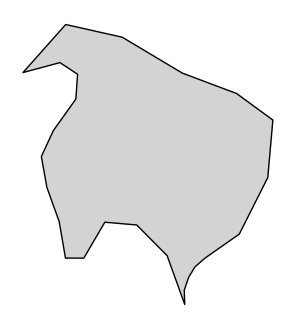

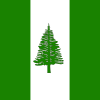


🌍 WORD BANK 🌍
--------------------------------------------------
Afghanistan                        Akrotiri Sovereign Base Area       Albania                            
Algeria                            Andorra                            Aruba                              
Ashmore and Cartier Islands        Austria                            Bahrain                            
Bajo Nuevo Bank (Petrel Is.)       Barbados                           Baykonur Cosmodrome                
Belarus                            Belgium                            Benin                              
Bhutan                             Bolivia                            Bosnia and Herzegovina             
Botswana                           Bulgaria                           Burkina Faso                       
Burundi                            Cameroon                           Central African Republic           
Chad                               Clipperton Island                  Coral Sea Island

Simbabwe is not a valid country name. Please try again.
Guess 1: Zimbabwe is 8099 miles SE from this country.
Guess 2: Guam is 3318 miles SE from this country.
Guess 3: Libya is 10604 miles E from this country.
Guess 4: Vatican is 10806 miles NE from this country.
Guess 5: Zambia is 8477 miles SE from this country.
Guess 6: Liberia is 10866 miles S from this country.
Guess 7: Guinea is 11150 miles S from this country.
Guess 8: Ethiopia is 8811 miles SE from this country.
Guess 9: Aruba is 8564 miles SW from this country.
Guess 10: Algeria is 11544 miles E from this country.
Guess 11: Monaco is 10960 miles NE from this country.
Guess 12: Jordan is 9540 miles E from this country.
Guess 13: Laos is 5395 miles SE from this country.
Guess 13: Norfolk Island

-------------
  WINNER
-------------


In [150]:
# Print intro message of game
intro_message()

# Get only polygon countries so center distance is correct
polygon_countries = world[world.geometry.geom_type == "Polygon"]

# Get random country, its name, and its center location
random_country, country_center, country_name = get_rand_country(polygon_countries)

# Variables for game loop
winner_found = False
countries_list = list(polygon_countries["ADMIN"].values)
guess_num = 0

# Plot country
plot_country(random_country)

# Display countries flag
display_flag(country_name)

# Word bank of countries
word_bank(countries_list)


# Game Loop
while not winner_found:

    # Ask the user to guess the country
    guess_country = input("Guess the country: ")
    

    # Winner Winner Chicken Dinner
    if guess_country == country_name:
        print(f"Guess {guess_num}: {guess_country}")
        winner()
        winner_found = True
        
    # Guess was incorrect, get dist and direction of guessed country to true country
    elif guess_country in polygon_countries["ADMIN"].values:
        
        # Get the center of the guessed country
        guess_center = Formulas.feature_center_shapely(polygon_countries[polygon_countries["ADMIN"] == guess_country].iloc[0])
        
        # Calculate distance and direction
        distance        = Formulas.haversine_miles(guess_center, country_center)
        direction_angle = Formulas.initial_bearing(guess_center, country_center)
        direction       = Formulas.bearing_to_compass(direction_angle)

        # Increment guess number
        guess_num += 1

        # Print distance and direction users guessed country was from the true country
        print(f"Guess {guess_num}: {guess_country} is {distance:.0f} miles {direction} from this country.")
        
    # Quitter
    elif guess_country.lower() == "quit":
        quitter(country_name)
        winner_found = True
        
    # Invalid country entered
    else:
        print(f"{guess_country} is not a valid country name. Please try again.")    